## Задача
*Представьте, что вы работаете в компании, которая разрабатывает мобильные игры. К вам пришел менеджер с рядом задач по исследованию нескольких аспектов мобильного приложения:*

- *В первую очередь, его интересует показатель retention. Напишите функцию для его подсчета.*
- *Помимо этого, в компании провели A/B тестирование наборов акционных предложений. На основе имеющихся данных определите, какой набор можно считать лучшим и на основе каких метрик стоит принять правильное решение.*
- *Предложите метрики для оценки результатов последнего прошедшего тематического события в игре.*

### Задание 1
Написать функцию, которая будет считать retention игроков (по дням от даты регистрации игрока).

In [1]:
#импорт библиотек

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import matplotlib.colors as mcolors
from scipy import stats
import numpy as np


In [2]:
#чтение файлов
reg_data = pd.read_csv('problem1-reg_data.csv', encoding = 'utf-8', sep = ';')
reg_data.head()

,reg_ts,uid
0,911382223,1
1,932683089,2
2,947802447,3
3,959523541,4
4,969103313,5


In [3]:
auth_data = pd.read_csv('problem1-auth_data.csv', encoding = 'utf-8', sep = ';')
auth_data.head()

,auth_ts,uid
0,911382223,1
1,932683089,2
2,932921206,2
3,933393015,2
4,933875379,2


In [4]:
reg_data.isnull().value_counts()

reg_ts  uid  
False   False    1000000
Name: count, dtype: int64

In [5]:
print(reg_data.dtypes)
print('Количество записей:',len(reg_data))

reg_ts    int64
uid       int64
dtype: object
Количество записей: 1000000


In [6]:
auth_data.isnull().value_counts()

auth_ts  uid  
False    False    9601013
Name: count, dtype: int64

In [7]:
print(auth_data.dtypes)
print('Количество записей:',len(auth_data))

auth_ts    int64
uid        int64
dtype: object
Количество записей: 9601013


In [8]:
# Преобразуем временные метки в даты
reg_data.loc[:, 'registration_date'] = pd.to_datetime(reg_data['reg_ts'], unit='s')
auth_data.loc[:, 'authentication_date'] = pd.to_datetime(auth_data['auth_ts'], unit='s')

In [9]:
# Детальный анализ временного распределения
start_date = reg_data['registration_date'].min()
end_date = reg_data['registration_date'].max()

total_days = (end_date - start_date).days
total_years = total_days / 365
days_with_registrations = reg_data['registration_date'].dt.date.nunique()

print(f"Период: {start_date} до {end_date}")
print(f"Всего дней в периоде: {total_days}")
print(f"Всего полных лет: {total_years:.1f}")
print(f"Дней с регистрациями: {days_with_registrations}")
print(f"Покрытие регистрациями: {days_with_registrations/total_days*100:.1f}% дней")

Период: 1998-11-18 09:43:43 до 2020-09-23 15:17:24
Всего дней в периоде: 7980
Всего полных лет: 21.9
Дней с регистрациями: 5110
Покрытие регистрациями: 64.0% дней


Смотреть ретеншн по всем ~22 годам нет смысла, так как это уже другое поколение игроков, поэтому для анализа возьмем последние 3 года

In [10]:
def calculate_monthly_retention(reg_data, auth_data, years_back=3):
    """
    Расчет месячного retention за указанное количество лет
    """
    # Создаем явные копии чтобы избежать предупреждений
    reg_data = reg_data.copy()
    auth_data = auth_data.copy()
    
    # Фильтруем данные за указанный период
    last_registration_date = reg_data['registration_date'].max()
    period_start = last_registration_date - timedelta(days=years_back*365)
    
    recent_reg_data = reg_data.loc[reg_data['registration_date'] >= period_start].copy()
    recent_user_ids = recent_reg_data['uid'].unique()
    recent_auth_data = auth_data.loc[auth_data['uid'].isin(recent_user_ids)].copy()
    
    print(f"Анализ retention за {years_back} г.")
    print(f"Период: {period_start.date()} - {last_registration_date.date()}")
    print(f"Количество пользователей: {len(recent_user_ids)}")
    
    # Создаем месячные когорты
    recent_reg_data.loc[:, 'cohort_month'] = recent_reg_data['registration_date'].dt.to_period('M')
    recent_reg_data.loc[:, 'cohort'] = recent_reg_data['cohort_month'].astype(str)
    
    # Словарь для хранения результатов
    retention_results = []
    cohort_sizes = {}
    
    # Анализируем каждую когорту
    for cohort_month in recent_reg_data['cohort'].unique():
        
        # Пользователи, зарегистрированные в этом месяце
        cohort_users = recent_reg_data.loc[recent_reg_data['cohort'] == cohort_month, 'uid'].unique()
        cohort_user_count = len(cohort_users)
        cohort_sizes[cohort_month] = cohort_user_count
        
        # Пропускаем когорты с малым количеством пользователей
        if cohort_user_count < 50:
            continue
            
        # Авторизации пользователей этой когорты
        cohort_authentications = recent_auth_data.loc[recent_auth_data['uid'].isin(cohort_users)].copy()
        
        # Находим даты регистрации для каждого пользователя когорты
        user_registration_dates = recent_reg_data.loc[recent_reg_data['cohort'] == cohort_month].groupby('uid')['registration_date'].min()
        cohort_authentications = cohort_authentications.merge(
            user_registration_dates.reset_index(), 
            on='uid'
        )
        
        # Вычисляем разницу в месяцах между авторизацией и регистрацией
        cohort_authentications.loc[:, 'months_since_registration'] = (
            (cohort_authentications['authentication_date'].dt.to_period('M') - 
             cohort_authentications['registration_date'].dt.to_period('M')).apply(lambda x: x.n)
        )
        
        # Фильтруем только будущие авторизации
        cohort_authentications = cohort_authentications.loc[cohort_authentications['months_since_registration'] >= 0]
        
        # Считаем retention для каждого месяца (до 36 месяцев максимум)
        max_months = min(36, years_back * 12)
        for month in range(0, max_months):
            
            # Количество уникальных пользователей, зашедших в этом месяце
            active_users_count = cohort_authentications.loc[
                cohort_authentications['months_since_registration'] == month, 'uid'
            ].nunique()
            
            # Retention rate в процентах
            retention_percentage = (active_users_count / cohort_user_count) * 100
            
            retention_results.append({
                'cohort_month': cohort_month,
                'month_number': month,
                'retention_rate': retention_percentage,
                'active_users': active_users_count,
                'cohort_size': cohort_user_count
            })
    
    return pd.DataFrame(retention_results), cohort_sizes


In [11]:
# Расчет retention
# Анализ за 3 года
retention_3y, sizes_3y = calculate_monthly_retention(reg_data, auth_data, years_back=3)
# Анализ за 1 год (для более свежих данных)
retention_1y, sizes_1y = calculate_monthly_retention(reg_data, auth_data, years_back=1)
# Анализ за 5 лет 
retention_5y, sizes_5y = calculate_monthly_retention(reg_data, auth_data, years_back=5)

Анализ retention за 3 г.
Период: 2017-09-24 - 2020-09-23
Количество пользователей: 834797
Анализ retention за 1 г.
Период: 2019-09-24 - 2020-09-23
Количество пользователей: 451294
Анализ retention за 5 г.
Период: 2015-09-25 - 2020-09-23
Количество пользователей: 950262


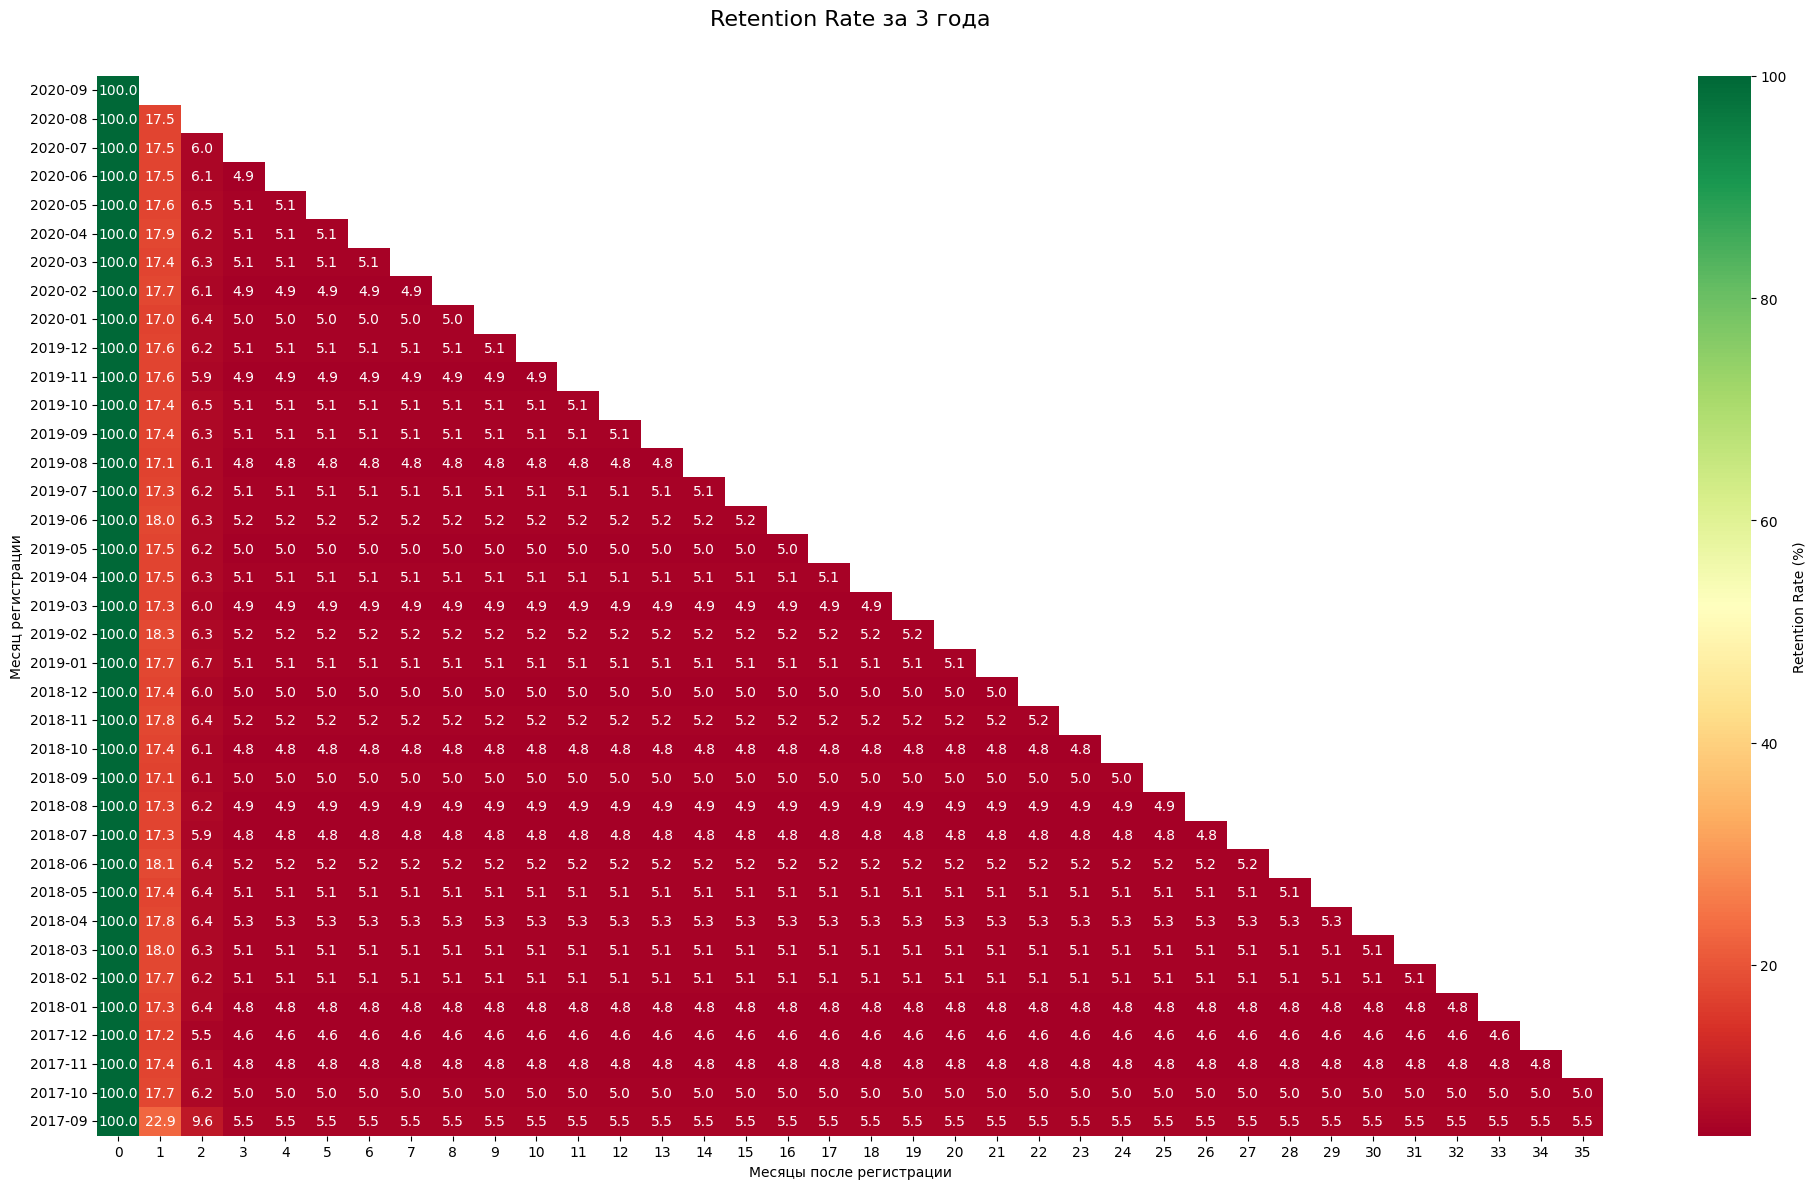

In [12]:
# Визуализация результатов
if not retention_3y.empty:
    
    # Создаем сводную таблицу для heatmap
    retention_pivot_table = retention_3y.pivot_table(
        index='cohort_month', 
        columns='month_number', 
        values='retention_rate', 
        aggfunc='mean',
        fill_value=0
    )
    
    # Сортируем когорты от новых к старым
    retention_pivot_table = retention_pivot_table.sort_index(ascending=False)
    retention_data_36_months = retention_pivot_table.iloc[:, :36]
    
    # Создаем маску для нулевых значений
    zero_mask = retention_data_36_months == 0
    
    # Создаем heatmap
    plt.figure(figsize=(20, 12))
    
    sns.heatmap(
        retention_data_36_months,
        annot=True,
        fmt='.1f',
        cmap='RdYlGn',
        cbar_kws={'label': 'Retention Rate (%)'},
        mask=zero_mask,  # Скрываем нулевые значения
        annot_kws={'size': 10}
    )
    
    plt.title('Retention Rate за 3 года\n', fontsize=16, pad=20)
    plt.xlabel('Месяцы после регистрации')
    plt.ylabel('Месяц регистрации')
    plt.tight_layout()
    plt.show()

In [14]:
# Ключевые данные retention 
average_retention = retention_3y.groupby('month_number')['retention_rate'].mean()

key_months = [1, 3, 6, 12, 24, 36]
for month in key_months:
    if month < len(average_retention):
        retention_value = average_retention[month]
        years = month // 12
        months = month % 12
        time_label = f"{years}г {months}м" if years > 0 else f"{month}м"
        print(f"Retention {time_label}: {retention_value:.2f}%")


Retention 1м: 17.20%
Retention 3м: 4.62%
Retention 6м: 4.21%
Retention 1г 0м: 3.39%
Retention 2г 0м: 1.76%


### Задание 2
*Имеются результаты A/B теста, в котором двум группам пользователей предлагались различные наборы акционных предложений. Известно, что ARPU в тестовой группе выше на 5%, чем в контрольной. При этом в контрольной группе 1928 игроков из 202103 оказались платящими, а в тестовой – 1805 из 202667.*

*Какой набор предложений можно считать лучшим? Какие метрики стоит проанализировать для принятия правильного решения и как?*

In [15]:
#Загрузка данных и базовый осмотр
ab_data = pd.read_csv('Проект_1_Задание_2.csv', sep=';')
ab_data.head()

,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b


In [16]:
ab_data.dtypes

user_id       int64
revenue       int64
testgroup    object
dtype: object

In [17]:
ab_data.isnull().value_counts()

user_id  revenue  testgroup
False    False    False        404770
Name: count, dtype: int64

In [18]:
#Переименуем группы в контрольную и тестовую, чтобы не путаться между а и б
ab_data['group'] = ab_data['testgroup'].map({'a': 'control', 'b': 'test'})
ab_data.head()

,user_id,revenue,testgroup,group
0,1,0,b,test
1,2,0,a,control
2,3,0,a,control
3,4,0,b,test
4,5,0,b,test


**Гипотезы**

ARPU:
- H1: ARPU тестовой группы > ARPU контрольной группы
- H0: ARPU тестовой группы <= ARPU контрольной группы

Конверсия:
- H1: Конверсия в покупку отличается между группами  
- H0: Конверсия в покупку одинакова в обеих группах

ARPPU:
- H1: ARPPU тестовой группы > ARPPU контрольной группы
- H0: ARPPU тестовой группы <= ARPPU контрольной группы

Распределение платежей:
- H1: Распределение платежей отличается между группами
- H0: Распределение платежей одинаково в обеих группах
    

In [19]:
# Разделим на группы
control = ab_data[ab_data['group'] == 'control']
test = ab_data[ab_data['group'] == 'test']

# Базовые статистики
control_size = len(control)
test_size = len(test)

print(f"Контрольная группа: {control_size} пользователей")
print(f"Тестовая группа: {test_size} пользователей")

Контрольная группа: 202103 пользователей
Тестовая группа: 202667 пользователей


In [20]:
# Считаем основные показатели для каждой группы
control_arpu = control['revenue'].mean()  # Средний доход на пользователя
test_arpu = test['revenue'].mean()

control_paying = (control['revenue'] > 0).sum()  # Количество платящих
test_paying = (test['revenue'] > 0).sum()

control_conversion = control_paying / len(control) * 100  # Конверсия в %
test_conversion = test_paying / len(test) * 100

# ARPPU - средний доход с платящего пользователя
control_arppu = control[control['revenue'] > 0]['revenue'].mean()
test_arppu = test[test['revenue'] > 0]['revenue'].mean()

print("Результаты по группам:")
print(f"ARPU - Контрольная: {control_arpu:.2f}, Тестовая: {test_arpu:.2f}")
print(f"Конверсия - Контрольная: {control_conversion:.2f}%, Тестовая: {test_conversion:.2f}%")
print(f"ARPPU - Контрольная: {control_arppu:.2f}, Тестовая: {test_arppu:.2f}")

Результаты по группам:
ARPU - Контрольная: 25.41, Тестовая: 26.75
Конверсия - Контрольная: 0.95%, Тестовая: 0.89%
ARPPU - Контрольная: 2664.00, Тестовая: 3003.66


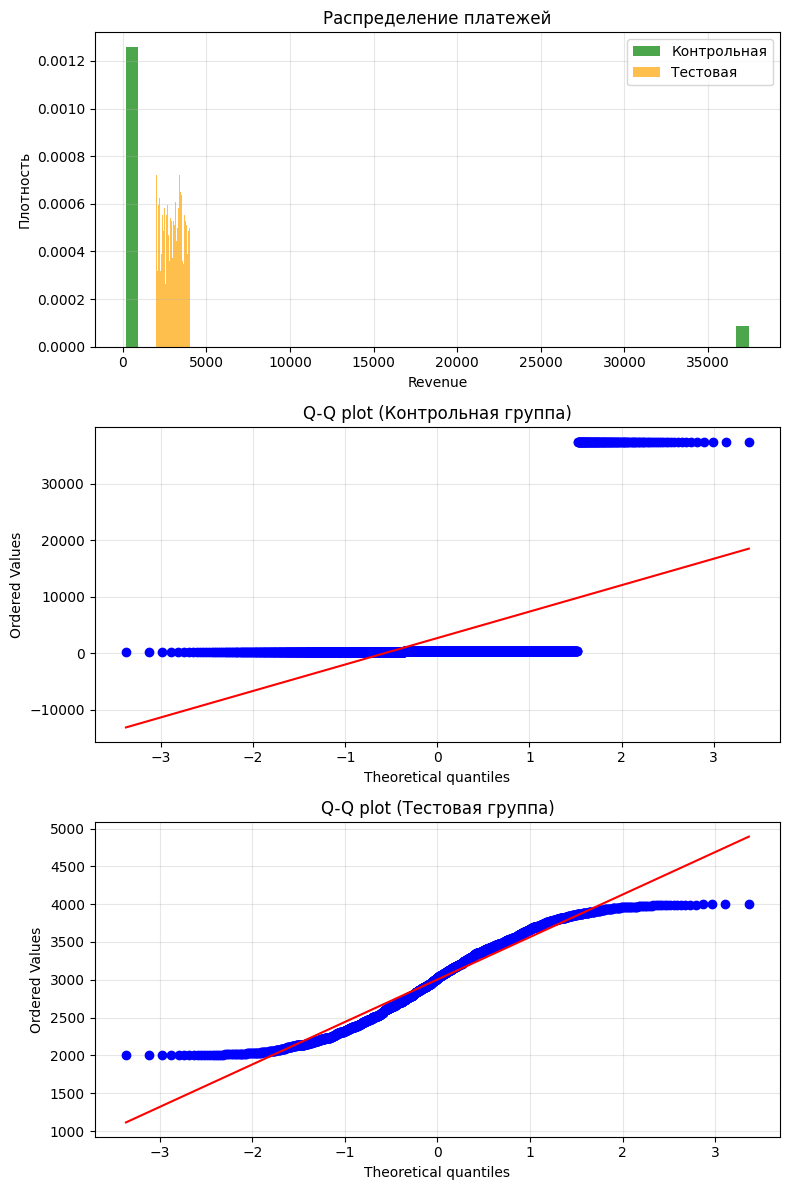

In [21]:
# Создаем переменные для платящих пользователей
control_paying_users = control[control['revenue'] > 0]['revenue']
test_paying_users = test[test['revenue'] > 0]['revenue']
# Визуализация для проверки нормальности распределения
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 12))

# Гистограммы распределения платежей
ax1.hist(control_paying_users, bins=50, alpha=0.7, color='green', label='Контрольная', density=True)
ax1.hist(test_paying_users, bins=50, alpha=0.7, color='orange', label='Тестовая', density=True)
ax1.set_title('Распределение платежей')
ax1.set_xlabel('Revenue')
ax1.set_ylabel('Плотность')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Q-Q plots для проверки нормальности
stats.probplot(control_paying_users, dist="norm", plot=ax2)
ax2.set_title('Q-Q plot (Контрольная группа)')
ax2.grid(True, alpha=0.3)

# Q-Q plot тестовой группы
stats.probplot(test_paying_users, dist="norm", plot=ax3)
ax3.set_title('Q-Q plot (Тестовая группа)')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Q-Q plot явно показывает, что распределение НЕ нормальное. Точки сильно отклоняются от прямой линии, особенно в "хвостах".

Проблема с t-тестом:
- t-тест предполагает нормальное распределение данных
- Наши данные имеют скошенное распределение с выбросами
- Использование t-теста может дать неверные результаты

Преимущества U-теста:
- Не требует нормальности - работает с любым распределением
- Устойчив к выбросам - не чувствителен к экстремальным значениям
- Сравнивает медианы - более надежно для скошенных данных
- Ранговый тест - преобразует данные в ранги, что устраняет проблемы распределения

In [22]:
#Статистические тесты

#Тест для конверсии
contingency_table = [
    [control_paying, len(control) - control_paying],
    [test_paying, len(test) - test_paying]
]
chi2, p_value_conv, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Тест конверсии (хи-квадрат): p-value = {p_value_conv:.4f}")

# Тест для ARPU (U-критерий Манна-Уитни)
mw_arpu, p_value_arpu = stats.mannwhitneyu(test['revenue'], control['revenue'])
print(f"Тест ARPU (Манна-Уитни): p-value = {p_value_arpu:.4f}")

# Тест для ARPPU (U-критерий Манна-Уитни)
mw_arppu, p_value_arppu = stats.mannwhitneyu(test_paying_users, control_paying_users)
print(f"Тест ARPPU (Манна-Уитни): p-value = {p_value_arppu:.4f}")


Тест конверсии (хи-квадрат): p-value = 0.0365
Тест ARPU (Манна-Уитни): p-value = 0.0627
Тест ARPPU (Манна-Уитни): p-value = 0.0000


C:\Users\tails\AppData\Local\Temp\ipykernel_32312\2501863952.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax4.boxplot([control_paying_users, test_paying_users], labels=['Контрольная', 'Тестовая'])


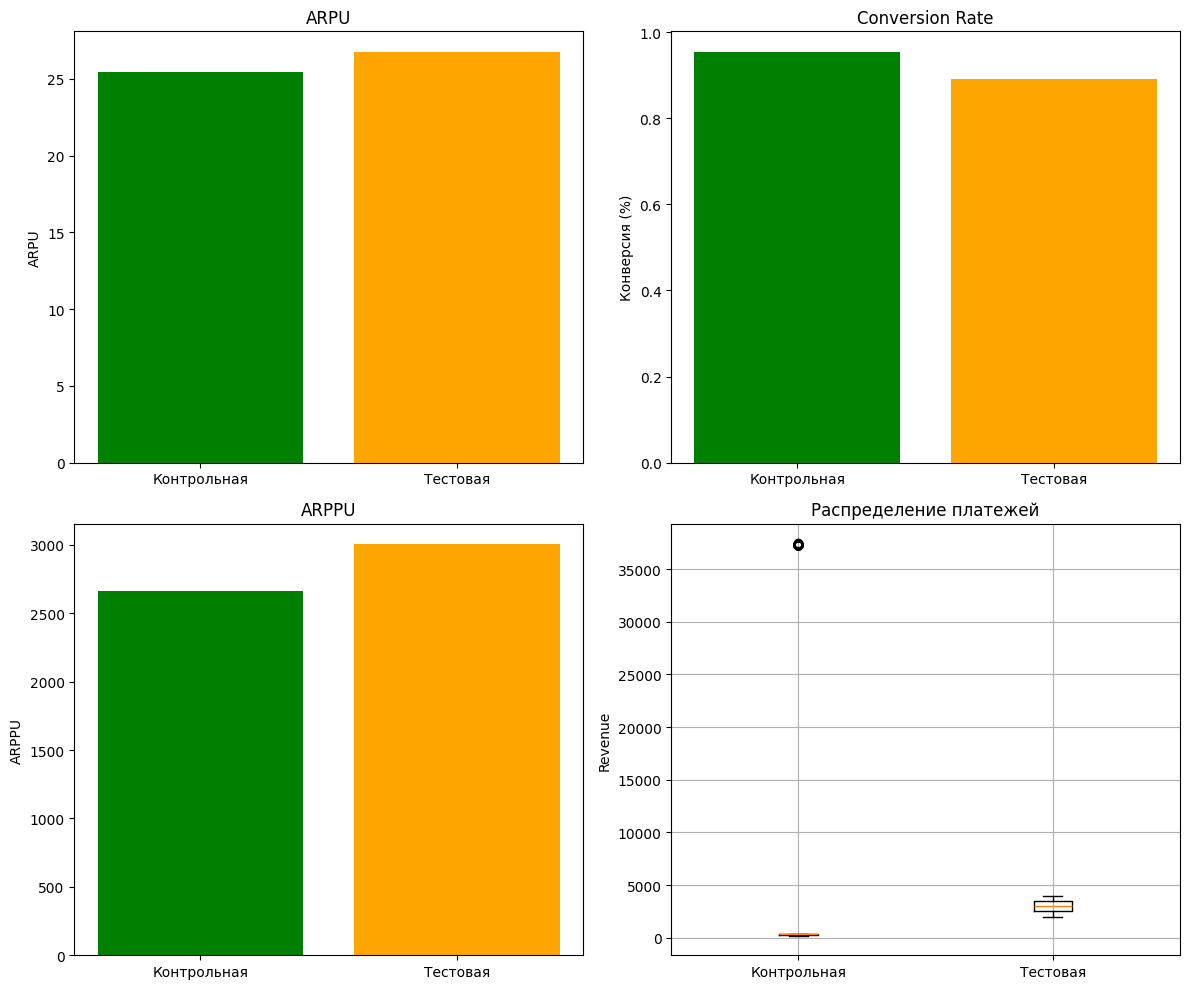

In [23]:
# Визуализация
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

# 1. ARPU
ax1.bar(['Контрольная', 'Тестовая'], [control_arpu, test_arpu], color=['green', 'orange'])
ax1.set_title('ARPU')
ax1.set_ylabel('ARPU')

# 2. Конверсия
ax2.bar(['Контрольная', 'Тестовая'], [control_conversion, test_conversion], color=['green', 'orange'])
ax2.set_title('Conversion Rate')
ax2.set_ylabel('Конверсия (%)')

# 3. ARPPU
ax3.bar(['Контрольная', 'Тестовая'], [control_arppu, test_arppu], color=['green', 'orange'])
ax3.set_title('ARPPU')
ax3.set_ylabel('ARPPU')

# 4. Боксплот платежей с выбросами
control_paying_users = control[control['revenue'] > 0]['revenue']
test_paying_users = test[test['revenue'] > 0]['revenue']

ax4.boxplot([control_paying_users, test_paying_users], labels=['Контрольная', 'Тестовая'])
ax4.set_title('Распределение платежей')
ax4.set_ylabel('Revenue')
plt.grid()

plt.tight_layout()
plt.show()

In [24]:
#Расчет прироста метрик
arpu_lift = (test_arpu - control_arpu) / control_arpu * 100
conversion_lift = (test_conversion - control_conversion) / control_conversion * 100
arppu_lift = (test_arppu - control_arppu) / control_arppu * 100

print(f"Прирост ARPU: {arpu_lift:+.1f}%")
print(f"Прирост конверсии: {conversion_lift:+.1f}%")
print(f"Прирост ARPPU: {arppu_lift:+.1f}%")



Прирост ARPU: +5.3%
Прирост конверсии: -6.6%
Прирост ARPPU: +12.7%


Были получены следующие результаты:
- ARPU вырос в тестовой группе на 5.3%, но это изменение не является статистически значимым (p-value = 0.0627)
- ARPPU увеличился на 12.7% со статистической значимостью (p-value = 0.0000)
- Конверсия (CR) снизилась в тестовой группе на 6.6% со статистической значимостью (p-value = 0.0365)

На основании проведенного анализа нельзя дать однозначный ответ о рекомендуемом наборе акционных предложений и требуется понимание бизнес-целей.
В случае, если поставлена задача увеличить общую выручку и средний чек платящих пользователей, следует использовать набор тестовой группы.
Если для бизнеса важнее привлечение большего количества платящих пользователей и охват аудитории, то следует использовать набор предложений контрольной группы.
Также можно сделать предположение о том, что группам была предложена разная структура акционных предложений, из-за чего отмечается статистически значимая разница в поведении пользователей - тестовые предложения привлекают меньше пользователей, но те кто платит, платят больше. Рекомендуется дополнительно проанализировать: Retention rate, LTV, распределение платежей по времени, сегментация пользователей по размеру платежей, поведение новых vs постоянных пользователей


### Задание 3

*В игре Plants & Gardens каждый месяц проводятся тематические события, ограниченные по времени. В них игроки могут получить уникальные предметы для сада и персонажей, дополнительные монеты или бонусы. Для получения награды требуется пройти ряд уровней за определенное время. С помощью каких метрик можно оценить результаты последнего прошедшего события?*

**Для стандартного события основные метрики:**

- Участие (%) - сколько игроков начали событие
- Completion Rate - сколько прошли до конца
- Средний прогресс - до какого уровня дошли
- Конверсия в покупки в событии
- Влияние на retention игроков


*Предположим, в другом событии мы усложнили механику событий так, что при каждой неудачной попытке выполнения уровня игрок будет откатываться на несколько уровней назад. Изменится ли набор метрик оценки результата? Если да, то как?*

**При усложнении механики (откаты уровней) добавляются:**

- Метрики сложности: глубина откатов, количество повторных прохождений
- Метрики фрустрации: на каких уровнях бросают, обращения в поддержку
- Метрики монетизации: покупки анти-откатных бустов

***Что меняется:***
Основной фокус смещается с "сколько прошли" на "как проходили". 
Completion Rate ожидаемо снизится, но может вырасти монетизация за счет продажи бустов. Важно балансировать сложность, чтобы не вызвать чрезмерную фрустрацию.